<a href="https://colab.research.google.com/github/Adithyaanil121/report/blob/main/ml_report(2)_26_09_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score



In [2]:
# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------

data = pd.read_csv("/content/Auto.csv")
print(data.head())



    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0         130    3504          12.0    70   
1  15.0          8         350.0         165    3693          11.5    70   
2  18.0          8         318.0         150    3436          11.0    70   
3  16.0          8         304.0         150    3433          12.0    70   
4  17.0          8         302.0         140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [3]:
# ------------------------------------------------------------
# 2. Select features
# ------------------------------------------------------------

X = data[["displacement"]]
y = data["mpg"]



In [4]:
# ------------------------------------------------------------
# 3. Split the data
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



In [5]:
# ------------------------------------------------------------
# 4. Linear Regression
# ------------------------------------------------------------

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predict
y_pred_linear = linear_model.predict(X_test)

# Calculate metrics
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("\nLinear Regression")
print("MSE =", mse_linear)
print("R-squared =", r2_linear)





Linear Regression
MSE = 21.227484289611397
R-squared = 0.5841057656051312


In [6]:
# ------------------------------------------------------------
# 5. Polynomial Regression
# ------------------------------------------------------------

degrees = [2, 3, 4]
results = []

for degree in degrees:

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create model
    model = LinearRegression()

    # Train model
    model.fit(X_train_poly, y_train)

    # Predict & evaluate
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([degree, mse, r2])

print("R2 :", r2_linear)

for result in results:
    degree = result[0]
    mse = result[1]
    r2 = result[2]

    print("\nPolynomial Degree:", degree)
    print("MSE:", mse)
    print("R2 :", r2)


R2 : 0.5841057656051312

Polynomial Degree: 2
MSE: 20.649054718307305
R2 : 0.5954385038809804

Polynomial Degree: 3
MSE: 20.81794078857357
R2 : 0.5921296453306659

Polynomial Degree: 4
MSE: 20.88841279063398
R2 : 0.5907489400646382


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


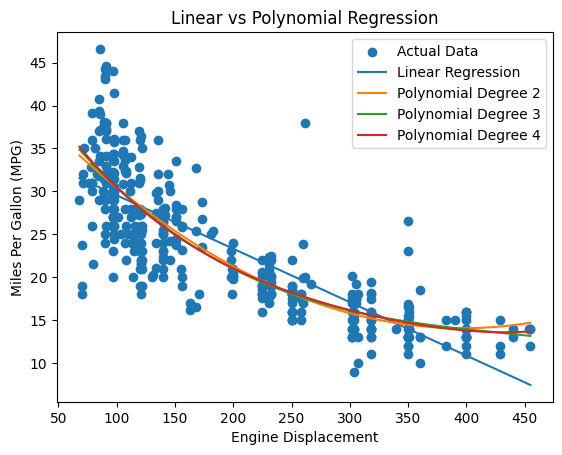

In [7]:

# ------------------------------------------------------------
# 7. Visualization
# ------------------------------------------------------------

# Sort the values for a smooth curve
X_plot = np.linspace(
    X["displacement"].min(),
    X["displacement"].max(),
    200
).reshape(-1, 1)

plt.scatter(
    X,
    y,
    label="Actual Data"
)

# Linear regression line
linear_line = linear_model.predict(X_plot)

plt.plot(
    X_plot,
    linear_line,
    label="Linear Regression"
)

# Polynomial curves
for degree in degrees:

    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    X_plot_poly = poly.transform(X_plot)
    y_plot = model.predict(X_plot_poly)

    plt.plot(
        X_plot,
        y_plot,
        label="Polynomial Degree " + str(degree)
    )

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()